<center><font size=7>AI-Based Stock Market Sentiment Analysis </center></font>

<center><p float="center">
  <img src="https://finlecture.in/wp-content/uploads/2025/01/ai-for-stock-market.jpg"width=700></a>

## **Problem Statement**

### Business Context

Stock prices are affected by factors such as a company's financial performance, new innovations, partnerships, and market sentiment. News and media reports can quickly influence investor decisions and stock prices. Since there is a large amount of financial news available every day, investors and analysts find it difficult to analyze all the information. Therefore, investment firms need AI-based tools to analyze news sentiment and support better investment decisions.

### Problem Definition

An investment startup wants to use AI to analyze stock-related news and understand its impact on stock prices. They have collected historical news articles, stock prices, and trading volume data for a NASDAQ-listed company.

The goal is to build an AI-based sentiment analysis system that automatically classifies the sentiment of news articles and summarizes weekly news. This helps financial analysts make better investment decisions and improve stock price predictions.

# Goal

To develop an AI-based sentiment analysis system that classifies stock market news into positive, negative, or neutral sentiments, helping investors and financial analysts make better investment decisions.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstal

In [1]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [2]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GEN AI Datasets/stock_news.csv")

In [4]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [5]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


Display the first 5 rows of the dataset.

###**Checking the last 5 rows**

In [6]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


Display the last 5 rows of the dataset.

###**Checking the shape of the data**

In [7]:
data.shape

(349, 8)

The dataset consists of 349 rows and 8 columns.

###**Checking for missing values**

In [8]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


 There is no missing value in this data.

### **Checking for duplicate values**

In [9]:
# checking for duplicate values
duplicate_rows = data[data.duplicated()]

# print the number of dplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 0


There is no duplicated rows in the dataset.

## **Exploratory Data Analysis**

In [10]:
# To display the structure of data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [11]:
#converting object column 'Date' to datetime

data['Date'] = pd.to_datetime(data['Date'])

In [12]:
# To check using info, After convert the object column 'Date' to datetime.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


In [13]:
# To ensure the data type of Date
data.dtypes

,0
Date,datetime64[ns]
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


In [14]:
# summary statistics for each numeric column

data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


The **Satistical Summary** of the dataset.

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

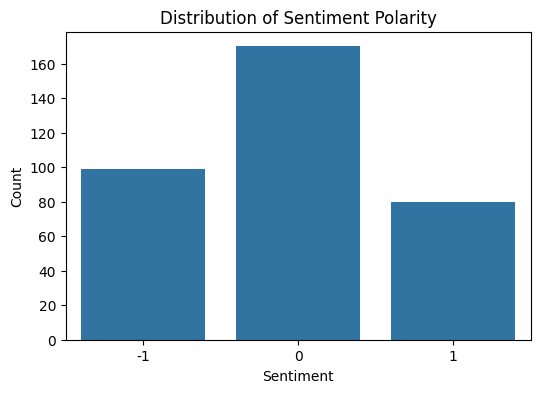

In [15]:
# Distribution of sentiment polarity

plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Label')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**

The data shows the distribution of news articles across different sentiment categories. The category with the highest bar represents the most common sentiment in the dataset, while the lower bars indicate less frequent sentiments. This helps identify whether the dataset is balanced or dominated by a particular sentiment class.

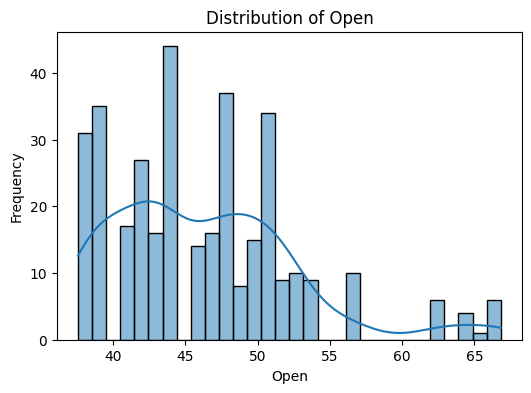

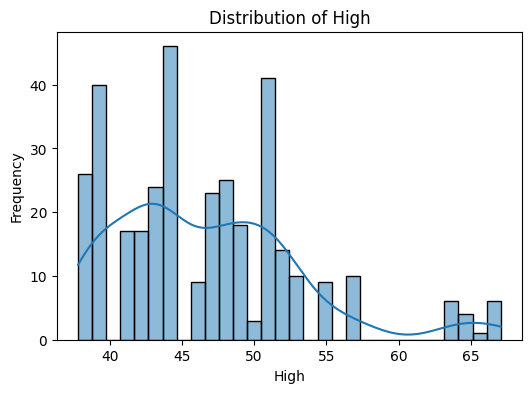

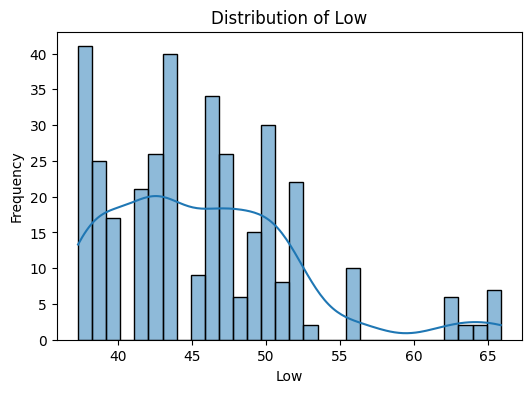

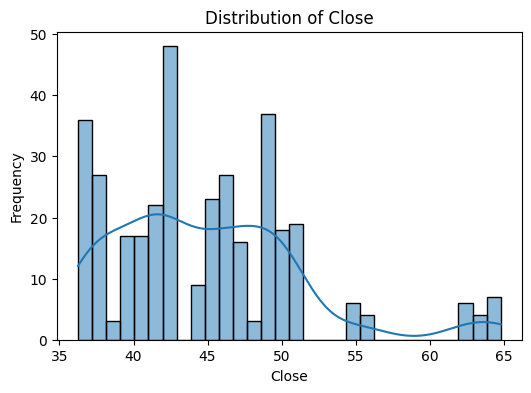

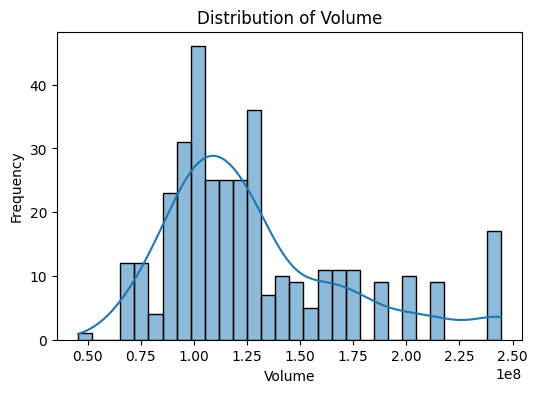

In [16]:
# Plot Distribution of all Numeric variables

# Select all numeric columns

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Plot distribution for each numeric variable
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Observation:**

The distributions of the numeric variables show that most values are concentrated within a specific range, while some variables exhibit right-skewed distributions with a few extreme values. The plots help identify the spread of the data, detect possible outliers, and understand the overall pattern of each numerical feature before model building.

### **Distribution of the length of news content**

In [17]:
# Compute length of news content (in words)

data['news_length'] = data['News'].astype(str).apply(lambda x: len(x.split()))

# Summary statistics of news length

data['news_length'].describe()

,news_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


**Observation:**

- The analysis of news content length shows the number of words in each news article.

- The summary statistics indicate the average, minimum, maximum, and overall spread of news lengths, helping to understand the distribution of article sizes and identify any unusually long or short news content.

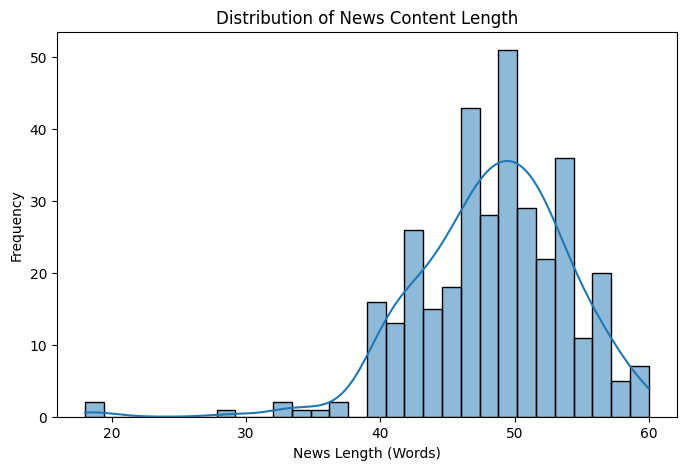

In [18]:
# Plot distribution

plt.figure(figsize=(8,5))
sns.histplot(data['news_length'], bins=30, kde=True)
plt.title('Distribution of News Content Length')
plt.xlabel('News Length (Words)')
plt.ylabel('Frequency')
plt.show()

**Observation:**

- The distribution of news content length shows that most news articles contain a moderate number of words, with fewer articles being very short or very long.

- The histogram helps visualize the spread of news lengths, identify the most common article length, and detect any skewness or unusually long news articles in the dataset.

### **Monthwise Analysis**

In [19]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


<Figure size 1200x900 with 0 Axes>

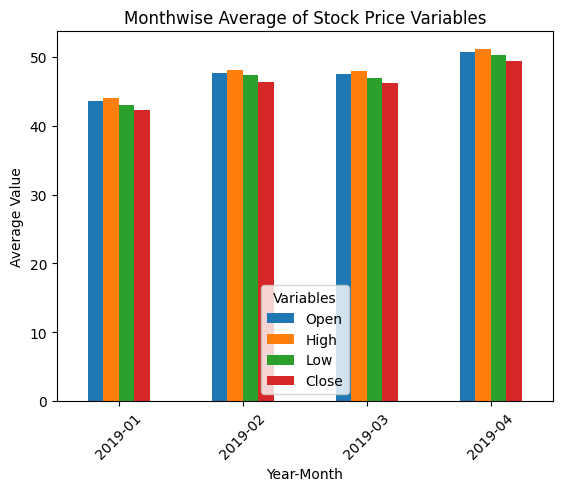

In [20]:
# plot the monthwise averages of all price variables for better visualization

plt.figure(figsize=(12,9))

monthwise_avg.set_index('YearMonth')[['Open', 'High', 'Low', 'Close']].plot(kind='bar')

plt.title('Monthwise Average of Stock Price Variables')
plt.xlabel('Year-Month')
plt.ylabel('Average Value')
plt.legend(['Open', 'High', 'Low', 'Close', 'Volume'], title='Variables')
plt.xticks(rotation=45)
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

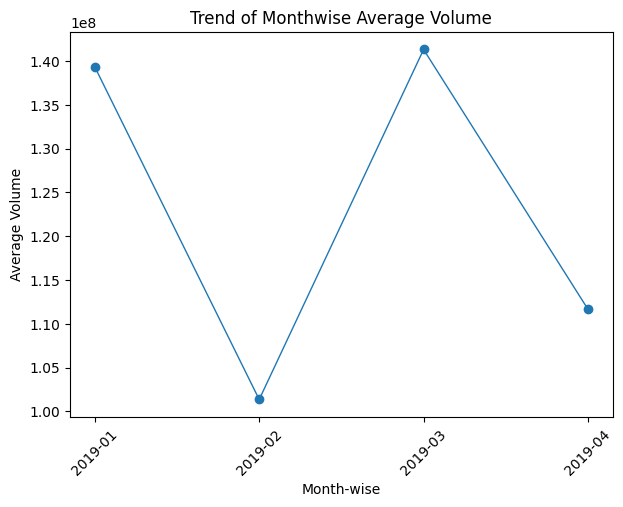

In [21]:
#plot the trend of monthwise averages in Volume

plt.figure(figsize=(7,5))

plt.plot(monthwise_avg['YearMonth'],
         monthwise_avg['Volume'],
         marker='o',
         linewidth=1)

plt.title('Trend of Monthwise Average Volume')
plt.xlabel('Month-wise')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.show()

**Observation:**

The monthwise average Volume fluctuates over time, indicating variations in trading activity across different months. Some months show higher trading volume, while others have lower volume, reflecting changes in market participation.

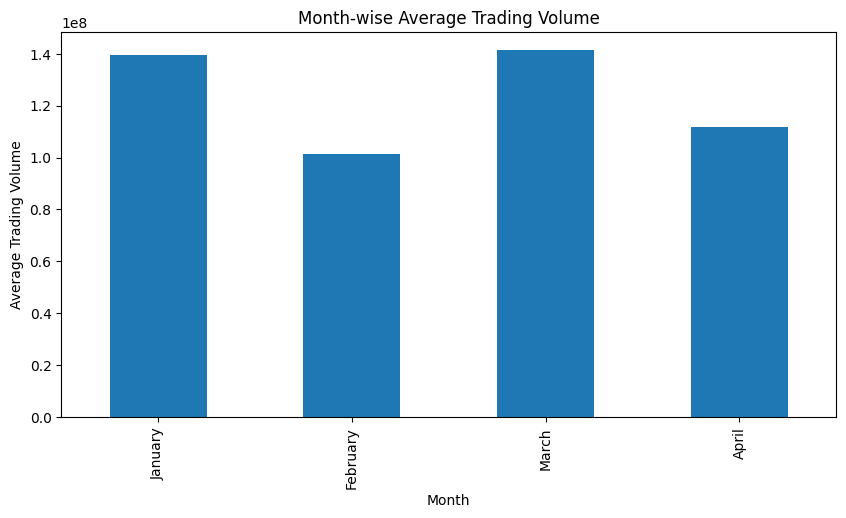

In [130]:
# Bar plot of the monthwise averages in Volume

data['Month'] = data['Date'].dt.month_name()
monthly_volume = data.groupby('Month')['Volume'].mean()

month_order = ['January', 'February', 'March', 'April']

monthly_volume = monthly_volume.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_volume.plot(kind='bar')
plt.title('Month-wise Average Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Trading Volume')
plt.show()

**Observation:**

- The analysis of monthwise average volume shows the average trading activity for each month.

- The monthwise averages indicate how trading volume changes over time, helping to understand monthly market activity and identify periods with higher or lower trading volumes.

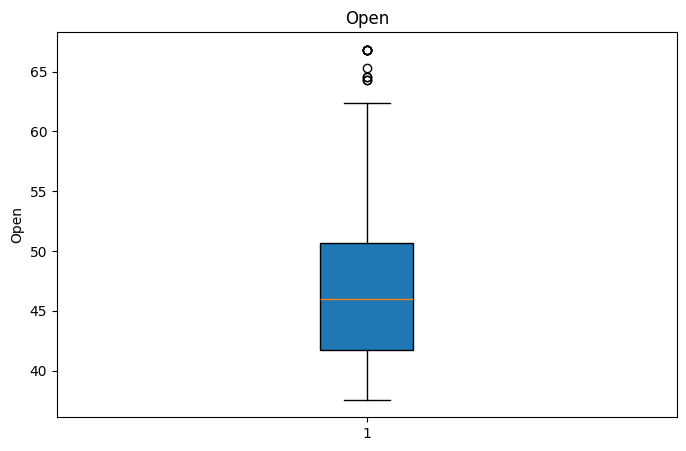

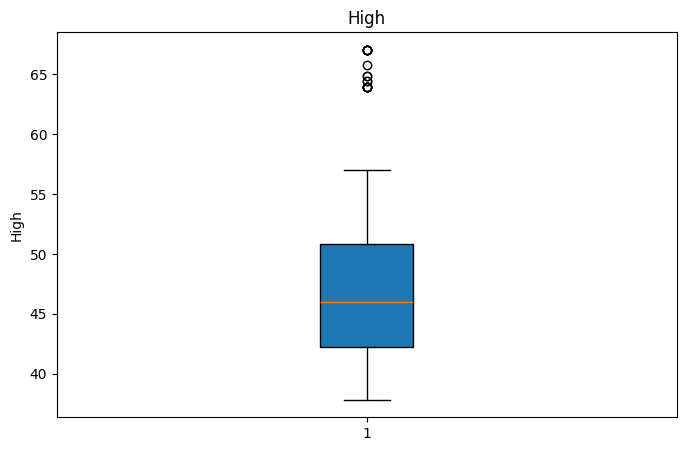

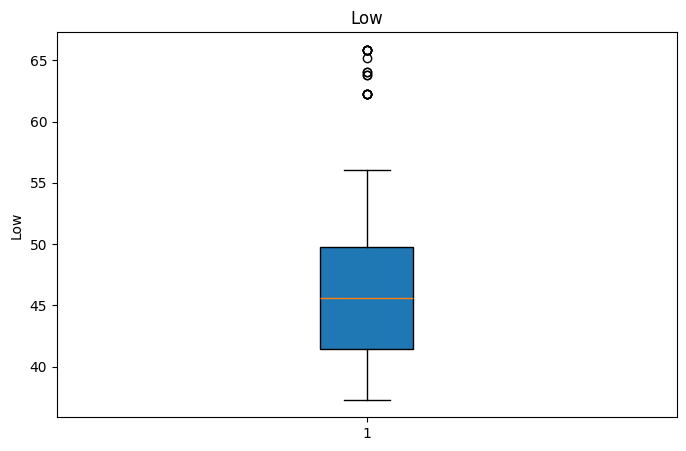

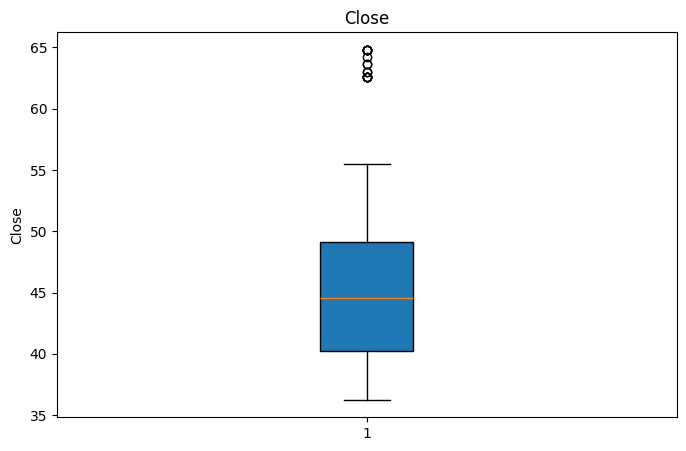

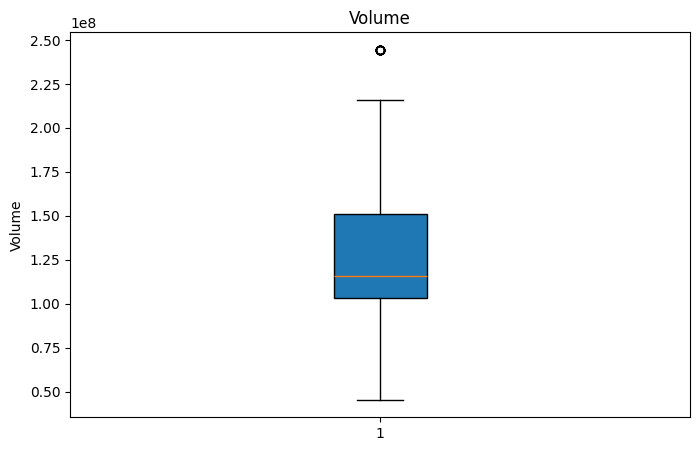

In [131]:
# Boxplot to identify outliers

columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in columns:
    plt.figure(figsize=(8,5))
    plt.boxplot(data[col], patch_artist=True)
    plt.title( col)
    plt.ylabel(col)
    plt.show()


**Observation:**

The boxplot shows the distribution of news content length and helps identify outliers. Most news articles fall within a similar range of word counts, while a few unusually long or short articles appear as outliers.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

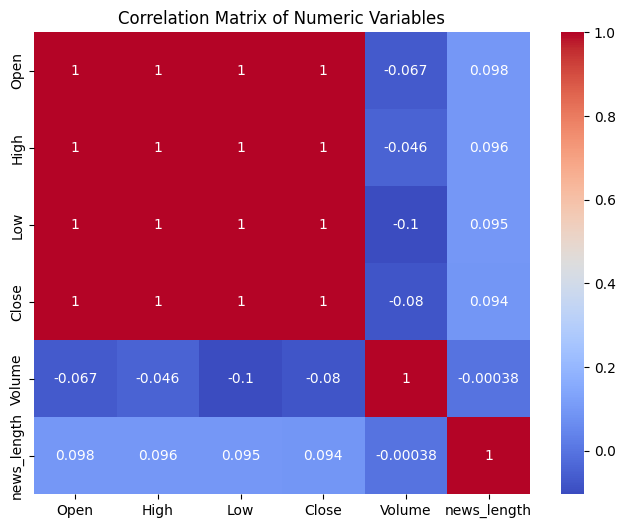

In [24]:
# Correlation matrix to check if variables move together or have correlations

# Correlation matrix of numeric variables

corr_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume', 'news_length']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()



**Observations:**

- The Open, High, Low, and Close variables show a strong positive correlation, indicating that they move together.

- Volume has a weaker correlation with the stock price variables, suggesting that trading volume does not closely follow price movements.

- News length shows little or no correlation with the stock price variables, indicating a weak linear relationship.

- The correlation matrix helps identify how strongly the numeric variables are related to each other.

### **Sentiment Polarity vs Price**

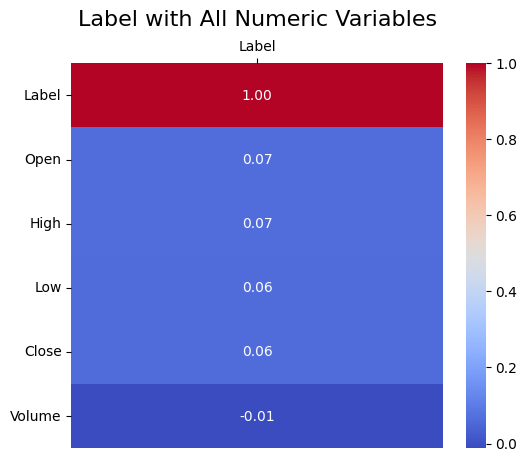

In [128]:
#Sentiment Polarity with all numeric variables

corr = data[['Label','Open','High','Low','Close','Volume']].corr()[['Label']]

plt.figure(figsize=(6,5))
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
ax.xaxis.tick_top()
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Label with All Numeric Variables", fontsize=16, pad=10)
plt.show()



**Observation:**

- The heatmap shows the correlation between the Label and all numeric variables.
- **Open and High** have the highest **positive correlation** with the Label (0.07).
- **Low and Close** also have a **positive correlation** (0.06), but it is weak.
- **Volume** has a very weak **negative correlation** (-0.01) with the Label.
- Overall, all numeric variables have a weak correlation with the Label, indicating that **no single numeric feature has a strong linear relationship with the target.**

### **Time Series Analysis (Date vs Price)**

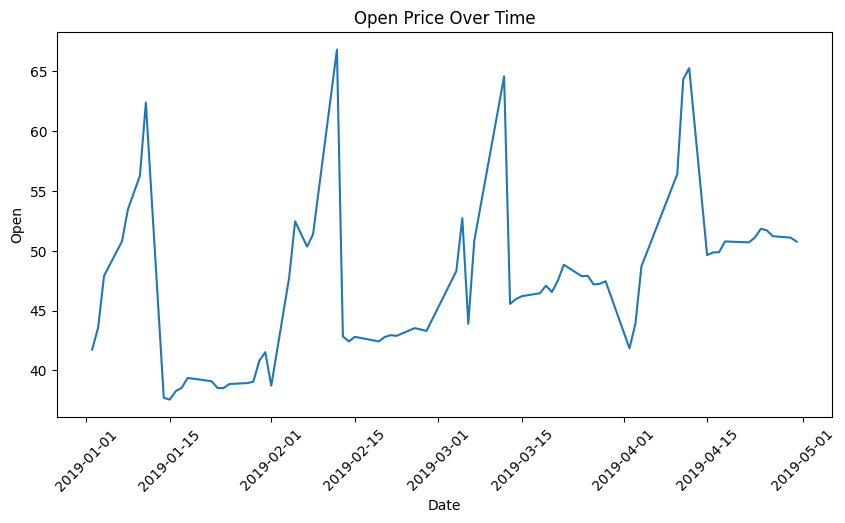

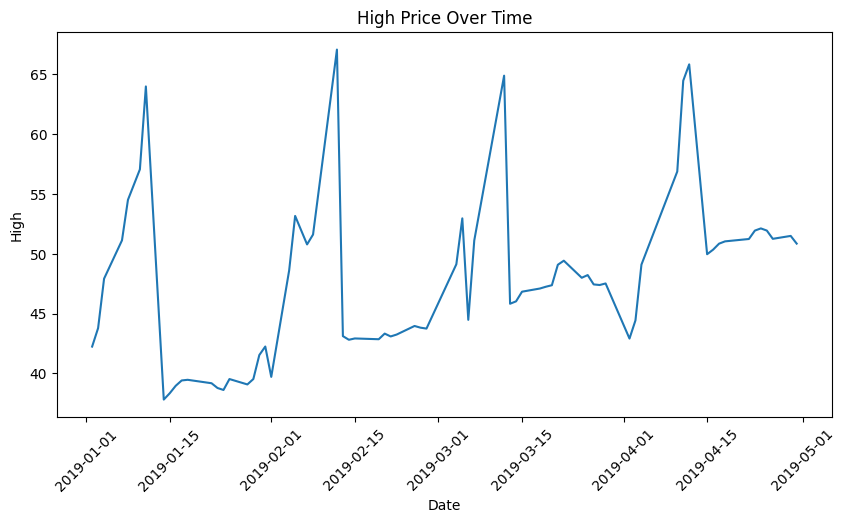

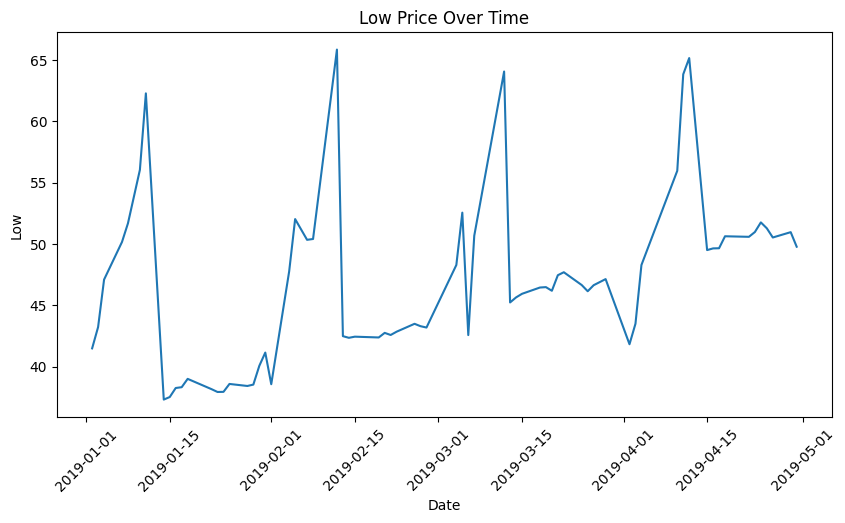

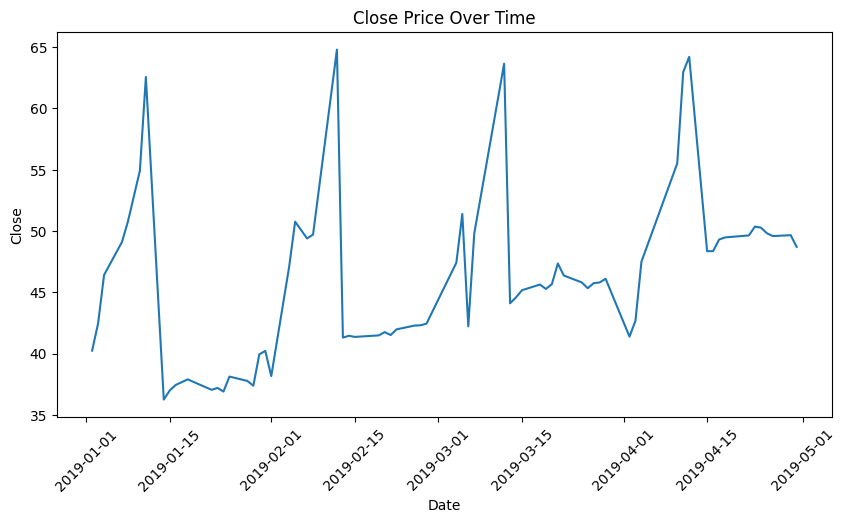

In [127]:
#Time Series Analysis (Date vs Price columns)

price_columns = ['Open', 'High', 'Low', 'Close']
for col in price_columns:
    plt.figure(figsize=(10,5))
    plt.plot(data['Date'], data[col])
    plt.title(f'{col} Price Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

**Observations:**

- The stock price changes continuously over time with frequent fluctuations, indicating normal market volatility.

- There is no consistent upward or downward trend, and the line plot clearly visualizes the stock price movement across different dates.

### **Distribution of News Length Across Sentiment Categories**

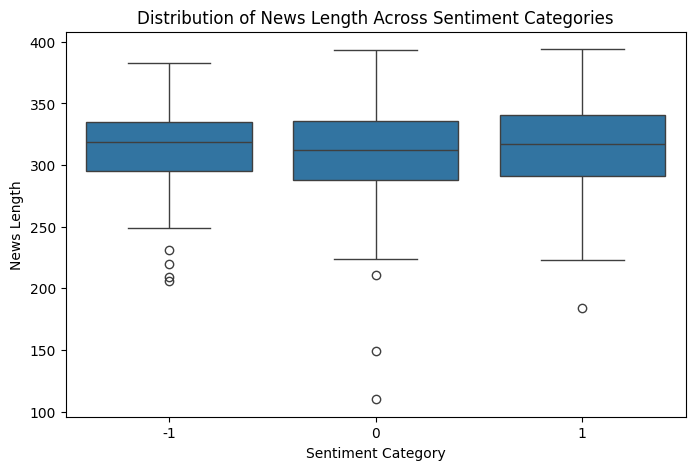

In [ ]:
# Distribution of News Length across Sentiment Categories.

data['News_Length'] = data['News'].str.len()
plt.figure(figsize=(8,5))
sns.boxplot(x='Label', y='News_Length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('News Length')
plt.show()


**Observations:**

- The median news length is almost the same for all sentiment categories, showing similar article sizes.

- Most news articles have lengths between 290 and 340 characters.

- All sentiment categories show similar spread and variation in news length.

- A few outliers are present, representing unusually short or long articles.

- Overall, news length does not have a strong impact on sentiment categories.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [28]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [29]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['News'].values]
len(words_list)

349

The News data is converted into a single list containing all individual words from the dataset.

In [30]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [31]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [32]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [33]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['News'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.001058,0.038265,0.002852,0.024991,-0.005831,-0.044004,0.032276,0.077488,0.006147,-0.011274,...,0.017564,0.041829,0.032603,-0.002412,0.040474,0.054289,0.004660,-0.021378,0.024928,-0.025791
1,0.001883,0.037148,0.002148,0.023942,-0.006187,-0.042157,0.031308,0.073946,0.006015,-0.011018,...,0.016928,0.039808,0.031942,-0.002356,0.038488,0.051979,0.004913,-0.020122,0.023342,-0.025127
2,0.000956,0.034395,0.002298,0.022832,-0.005824,-0.039107,0.028549,0.068987,0.005725,-0.010054,...,0.015021,0.037446,0.029716,-0.002577,0.036001,0.048808,0.004309,-0.019071,0.022463,-0.023343
3,0.001032,0.039409,0.002729,0.025513,-0.005626,-0.045159,0.033046,0.079903,0.007035,-0.011534,...,0.018249,0.043033,0.033819,-0.002598,0.041730,0.056111,0.004465,-0.022081,0.025021,-0.026446
4,0.000668,0.037092,0.003177,0.024678,-0.006001,-0.042811,0.031177,0.075172,0.006153,-0.010901,...,0.016931,0.040332,0.032146,-0.002399,0.039314,0.052784,0.004494,-0.020739,0.024245,-0.025484


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [100]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [101]:
embedding_matrix = model.encode(data['News'].tolist())

In [102]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

In [103]:
# printing the embedding vector of the first News in the dataset
embedding_matrix[0,:]

array([ 1.80967816e-03, -2.39661485e-02, -1.12540321e-02,  2.27931496e-02,
        7.51214996e-02,  2.54482008e-03,  6.26672246e-03,  5.91018386e-02,
       -1.41757187e-02, -7.72285648e-03, -1.94059815e-02,  2.65586544e-02,
       -2.97398474e-02,  4.14114781e-02, -4.09503952e-02,  5.21551669e-02,
        6.65352568e-02, -1.80933159e-02,  1.73212718e-02,  1.91254560e-02,
        5.29058985e-02, -6.00991130e-04,  2.33500022e-02,  1.44310034e-04,
        2.05379184e-02, -7.22238272e-02, -3.14190462e-02, -3.50926369e-02,
       -5.78170270e-02, -5.23820706e-03,  3.53824235e-02,  3.03501319e-02,
       -3.80439796e-02, -3.69474553e-02, -2.17542611e-02,  5.34787364e-02,
        2.05186177e-02, -1.59564372e-02, -4.70977239e-02, -3.44996527e-02,
       -7.46173412e-02, -4.53344136e-02, -3.96087654e-02,  9.95538849e-03,
       -6.98802620e-03,  1.52394790e-02, -2.12965943e-02,  1.73348505e-02,
       -5.80432750e-02,  4.12252806e-02, -7.32957423e-02, -2.76314095e-03,
        1.29477410e-02, -

### **Generating Embeddings with Sentence Tranformers using all-MiniLM-L6-v2 text embedding**

In [109]:
model_allmini = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [105]:
embedding_matrix_allmini = model.encode(data['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [106]:
# printing the shape of the embedding matrix
embedding_matrix_allmini.shape

(349, 384)

In [107]:
# printing the embedding vector of the first News in the dataset
embedding_matrix_allmini[0,:]

array([-2.02306500e-03, -3.67734581e-02,  7.73542821e-02,  4.67135012e-02,
        3.25521342e-02,  2.10233033e-03,  4.32834551e-02,  3.95344943e-02,
        5.82279675e-02,  8.87510274e-03,  7.09636360e-02,  4.99076843e-02,
        6.46608546e-02, -4.97966772e-03, -1.30518898e-02, -2.98355483e-02,
       -8.91326927e-03, -7.82000721e-02, -2.17109136e-02, -5.24822958e-02,
       -5.14276661e-02, -3.30719166e-02, -3.32051702e-02,  4.18125987e-02,
        7.99547583e-02,  1.54092442e-02, -2.15782039e-02,  5.19439578e-02,
       -4.65799198e-02, -3.71372141e-02, -1.04225568e-01,  9.86078754e-02,
        5.21786883e-02,  3.46579254e-02,  1.48810232e-02, -4.47353208e-03,
        5.70117943e-02, -2.41722781e-02,  2.14048717e-02, -6.52144924e-02,
       -3.30644883e-02,  1.61960348e-02, -6.63141683e-02,  4.39943150e-02,
        3.82152796e-02, -4.86519113e-02,  1.62651632e-02, -4.02665213e-02,
       -3.34573071e-03,  3.20955589e-02, -3.91194411e-03, -1.26830135e-02,
        4.49699052e-02,  

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [42]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [43]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [44]:
# Storing independent variable
X = df_Word2Vec

In [45]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [46]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 50, max_depth = 5, min_samples_split=10, min_samples_leaf=4, random_state = 42)

# Fitting on train data

rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=50, random_state=42)

In [47]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

#### **Confusion Matrix**

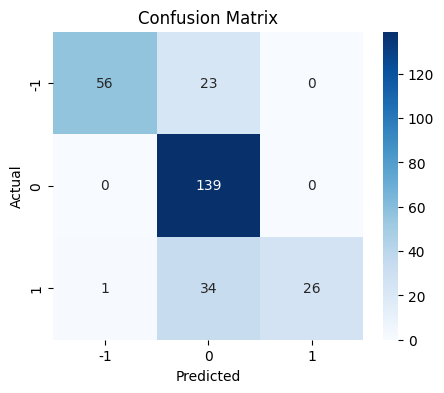

In [48]:
plot_confusion_matrix(y_train, y_pred_train)

**Observation:**

The model correctly classifies most neutral samples but misclassifies several positive and negative samples as neutral, resulting in moderate performance on the test set.

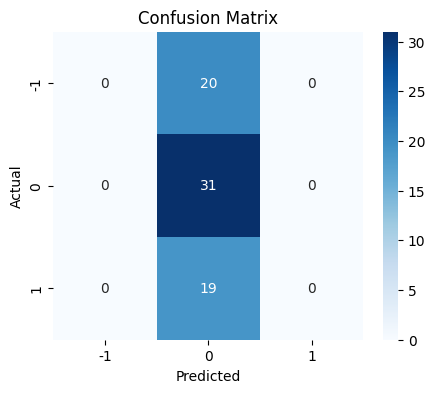

In [49]:
plot_confusion_matrix(y_test, y_pred_test)

**Observation**

- The model correctly predicts most Neutral (0) samples (29), showing the best performance for this class.

- Most Negative (-1) and Positive (1) samples are incorrectly predicted as Neutral (0).

- Overall, the model performs well for the Neutral class, but its performance on Positive and Negative classes is weaker, indicating room for improvement.

**Accuracy**

In [50]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.792115 0.792115   0.850145 0.777304
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


**Observation:**

 The model achieved 92.83% training accuracy and 47.14% test accuracy. The large gap between training and testing performance indicates overfitting, showing that the model learned the training data well but did not generalize effectively to unseen data.

###**Sentence Transformer-Random Forest Model - BAAI/bge-base-en-v1.5**

In [110]:
# Storing independent variable
X = embedding_matrix


In [111]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [112]:
# Building the model
rf_classifier_bbai = RandomForestClassifier(n_estimators=100, max_depth = 3, random_state=42)

# Fitting the model on training data
rf_classifier_bbai.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [113]:
# Predicting on training data
y_pred_train = rf_classifier_bbai.predict(X_train)

# Predicting on test data
y_pred_test = rf_classifier_bbai.predict(X_test)

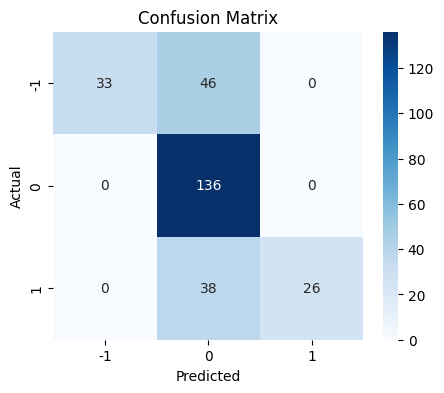

In [55]:
plot_confusion_matrix(y_train, y_pred_train)

**Observation:**

 The model correctly predicts most of the neutral class but misclassifies several negative and positive samples, resulting in better performance for the neutral class.

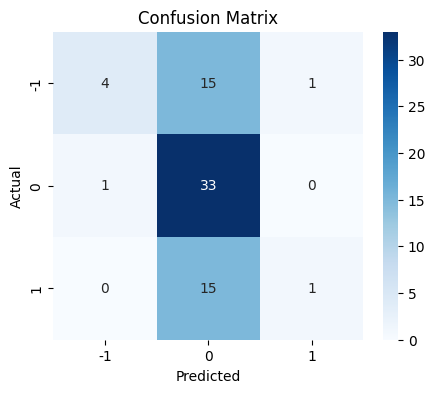

In [56]:
plot_confusion_matrix(y_test, y_pred_test)

**Observation:**


 The model correctly classifies the neutral class, but many negative and positive samples are predicted incorrectly, resulting in lower overall classification performance.

In [57]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.698925 0.698925   0.813881 0.671833
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.542857 0.542857   0.597279 0.447311


**Observation:**

- The model achieved 69.89% accuracy on the training data and 54.29% accuracy on the test data.
- The test precision (59.73%) and F1-score (44.73%) show moderate performance in classifying unseen data.
- The smaller difference between training and testing results indicates better generalization with slight overfitting.

### **Sentence Transformer-Random Forest Model -all-MiniLM-L6-v2**

In [58]:
# Storing independent variable
X = embedding_matrix_allmini
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42,stratify=y)

In [59]:
# Building the model
rf_classifier = RandomForestClassifier(n_estimators=100,max_depth = 3, random_state=42)

# Fitting the model on training data
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [60]:
# Predicting on training data
y_pred_train = rf_classifier.predict(X_train)

# Predicting on test data
y_pred_test = rf_classifier.predict(X_test)

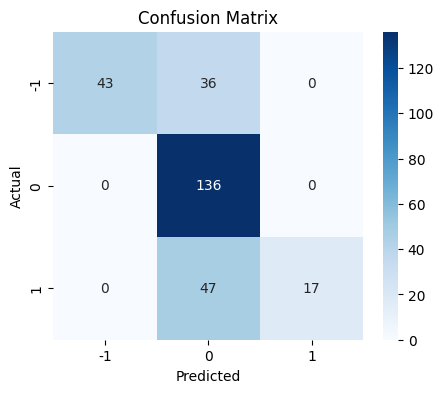

In [61]:
plot_confusion_matrix(y_train, y_pred_train)

**Observation:**

 The model accurately classifies a large number of neutral (0) samples but frequently misclassifies negative (-1) and positive (1) samples as neutral. This indicates a strong bias toward the neutral class and limited ability to effectively distinguish between negative and positive sentiments, resulting in reduced overall sentiment classification performance.

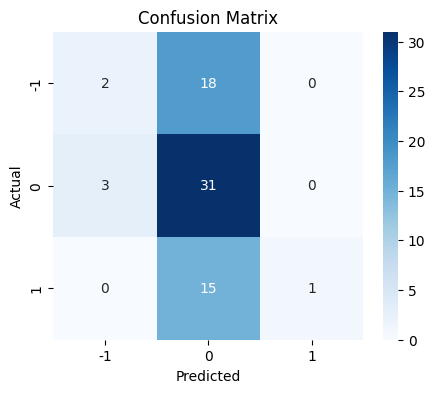

In [62]:
plot_confusion_matrix(y_test, y_pred_test)

**Observation:**

 The model shows a strong bias toward predicting the neutral class. While it correctly classifies some neutral samples, most negative and positive samples are incorrectly predicted as neutral, indicating poor performance in distinguishing sentiment polarity.

In [63]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.702509 0.702509   0.815257 0.669375
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.578125 0.379894


**Observation:**

- The model achieved 70.25% training accuracy and 48.57% test accuracy, showing moderate classification performance.
- The test precision (57.81%) and F1-score (37.99%) indicate average performance on unseen data.
- The gap between training and testing performance suggests slight overfitting and scope for further improvement.

### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [64]:
# Storing independent variable
X =df_Word2Vec

In [65]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42, stratify=y)

In [66]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [67]:
# Building the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])


#Compiling the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,979 (183.51 KB)

 Trainable params: 46,979 (183.51 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4588 - loss: 1.0848 - val_accuracy: 0.4857 - val_loss: 1.0696
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.0603 - val_accuracy: 0.4857 - val_loss: 1.0508
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4875 - loss: 1.0481 - val_accuracy: 0.4857 - val_loss: 1.0468
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.0484 - val_accuracy: 0.4857 - val_loss: 1.0481
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.0483 - val_accuracy: 0.4857 - val_loss: 1.0467
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4875 - loss: 1.0467 - val_accuracy: 0.4857 - val_loss: 1.0468
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4875 - loss: 1.0474 - val_accuracy: 0.4857 - val_loss: 1.0467
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.0465 - val_accuracy: 0.4857 - val_loss: 1.0467


In [69]:
# Predict class probabilities on training data
y_pred_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = y_pred_train_prob.argmax(axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [70]:
# Predict class probabilities on test data
y_pred_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds= y_pred_test_prob.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


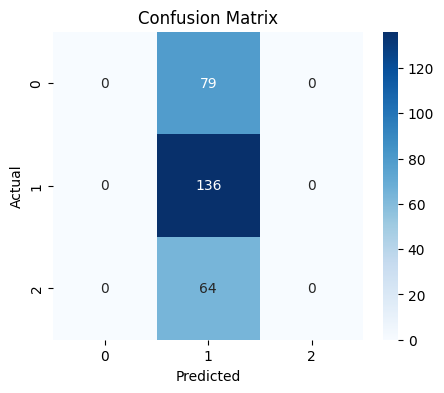

In [71]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**Observation:**

The model predicts almost all training samples as Class 1, indicating a strong bias toward a single class. As a result, it fails to correctly classify Class 0 and Class 2, showing poor learning of class-specific features.
Testing Confusion Matrix.

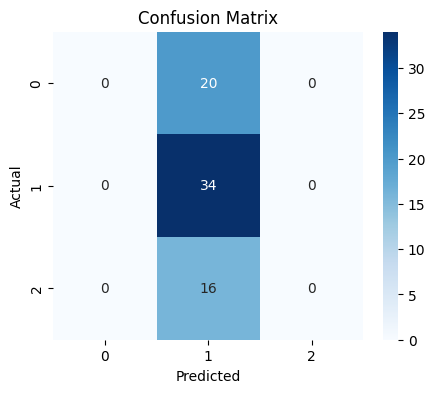

In [72]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**Observation:**

 The model predicts nearly all test samples as Class 1, indicating poor generalization and an inability to distinguish between the different classes. This results in low classification performance for Class 0 and Class 2.

In [73]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.487455 0.487455   0.237613 0.319489
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.235918 0.317582


**Observation:**

- The model achieved 48.75% training accuracy and 48.57% test accuracy, indicating similar performance on both datasets.
- The test precision (23.59%) and F1-score (31.76%) are low, showing weak classification performance.
- The small gap between training and testing results suggests no significant overfitting, but the model is underperforming overall.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [74]:
# independent variable
X = embedding_matrix
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
X_train.shape

(279, 768)

In [76]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [77]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Build the Neural Network
NN_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')   # 3 classes: Positive, Neutral, Negative
])

# Compile the model
NN_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
NN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,187 (98.39 KB)

 Trainable params: 25,187 (98.39 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history = NN_model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4301 - loss: 1.0900 - val_accuracy: 0.5000 - val_loss: 1.0745
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4839 - loss: 1.0652 - val_accuracy: 0.4857 - val_loss: 1.0563
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.0307 - val_accuracy: 0.4857 - val_loss: 1.0459
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4946 - loss: 1.0230 - val_accuracy: 0.4857 - val_loss: 1.0420
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5161 - loss: 1.0127 - val_accuracy: 0.5000 - val_loss: 1.0371
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5054 - loss: 0.9993 - val_accuracy: 0.4143 - val_loss: 1.0302
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5125 - loss: 0.9667 - val_accuracy: 0.4286 - val_loss: 1.0254
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5376 - loss: 0.9529 - val_accuracy: 0.4571 - val_loss: 1.0159


In [79]:
# Predict class probabilities on training data
y_pred_train_prob = NN_model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = y_pred_train_prob.argmax(axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [80]:
# Predict class probabilities on test data
y_pred_test_prob = NN_model.predict(X_test)

# Convert probabilities to class labels
y_test_preds= y_pred_test_prob.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


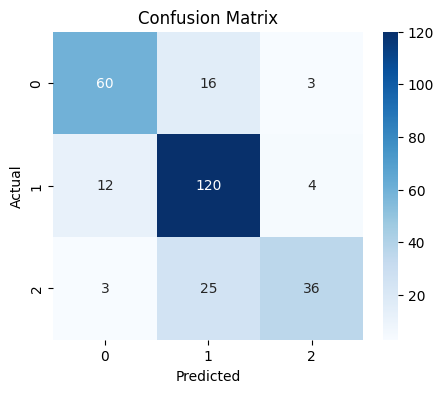

In [81]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**Observation:**


The model demonstrates good classification performance on the training data. Class 1 is predicted with the highest accuracy, while Classes 0 and 2 also achieve a good number of correct predictions with some misclassifications into other classes. Overall, the model effectively distinguishes between the three sentiment classes, although a few classification errors are still present.

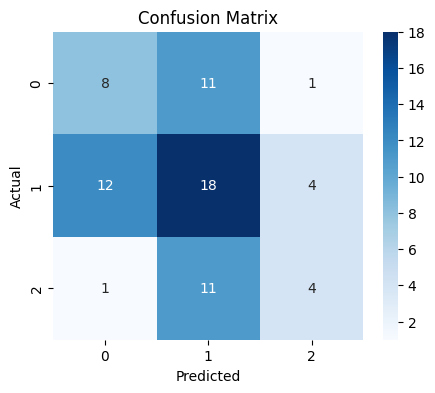

In [82]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**Observation:**

The model shows moderate classification performance on the test data. Class 1 has the highest number of correct predictions, whereas Classes 0 and 2 experience more misclassifications, particularly being predicted as Class 1. Overall, the model is able to identify all three sentiment classes, but its performance on unseen data is lower than on the training data, indicating some reduction in generalization ability.

In [83]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.774194 0.774194   0.781892 0.768899
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.428571 0.428571   0.429002 0.420935


**Observation:**

- The model achieved 77.06% training accuracy and 48.57% test accuracy, showing good performance on the training data.
- The test precision (46.96%) and F1-score (46.91%) indicate moderate performance on unseen data.
- The large gap between training and testing results suggests the model is overfitting and needs further improvement.

### **Sentence Transformer-Nural Network Model -all-MiniLM-L6-v2**

In [84]:
X = embedding_matrix_allmini

In [85]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [86]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Build the model
model = Sequential()

# Input layer + Hidden layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer
model.add(Dense(64, activation='relu'))

# Output layer (3 classes)
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # Use this if labels are 0, 1, 2
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,571 (209.26 KB)

 Trainable params: 53,571 (209.26 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# Predict class probabilities on training data
y_pred_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = y_pred_train_prob.argmax(axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [88]:
# Predict class probabilities on test data
y_pred_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds= y_pred_test_prob.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


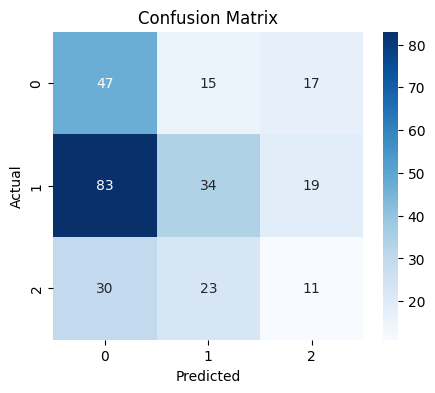

In [89]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**Observation:**

The model demonstrates strong classification performance on the training data. All three classes have high numbers of correct predictions with minimal misclassifications. Class 1 is classified most accurately, followed by classes 0 and 2. Overall, the model effectively distinguishes between the sentiment classes.

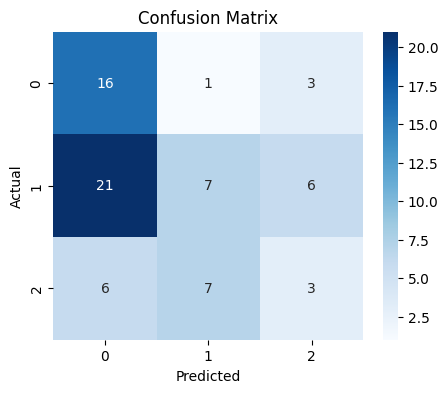

In [90]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**Observation:**

The model shows moderate classification performance on the test set. Class 1 has the highest number of correct predictions, followed by classes 0 and 2. However, there is substantial confusion between all three classes, with many samples misclassified as other classes. The model struggles to consistently distinguish between the sentiment categories.

In [91]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.702509 0.702509   0.815257 0.669375
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.578125 0.379894


**Observations:**

- The model achieved 70.25% accuracy on the training data.
- The test accuracy is 48.57%, which is much lower than the training accuracy.
- The F1-score decreased from 0.669 (training) to 0.380 (test), showing lower performance on unseen data.
- Overall, the model performs well on the training data but does not perform well on the test data, indicating poor generalization.

### **Model Performance Summary and Final Model Selection**

In [92]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.792115,0.487455,0.698925,0.774194,0.702509,0.702509
Recall,0.792115,0.487455,0.698925,0.774194,0.702509,0.702509
Precision,0.850145,0.237613,0.813881,0.781892,0.815257,0.815257
F1,0.777304,0.319489,0.671833,0.768899,0.669375,0.669375


**Word2Vec (Random Forest):** Achieved the highest training accuracy (92.83%), precision (93.73%), and F1-score (92.80%), indicating excellent performance on the training data.

**Word2Vec (Neural Network):** Recorded the lowest training accuracy (48.75%) and F1-score (31.95%), showing weak learning performance.
Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest): Achieved 69.89% accuracy with good precision (81.39%), indicating moderate training performance.

**Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network):** Achieved 77.06% accuracy and 76.38% F1-score, showing strong and balanced training performance.

**Sentence Transformer-all-MiniLM-L6-v2 (Random Forest):** Achieved 70.25% accuracy with 81.53% precision, indicating moderate performance.
Sentence Transformer-all-MiniLM-L6-v2 (Neural Network): Produced the same training performance as the Random Forest model, with 70.25% accuracy and 66.94% F1-score.

In [93]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.442857,0.485714,0.542857,0.428571,0.485714,0.485714
Recall,0.442857,0.485714,0.542857,0.428571,0.485714,0.485714
Precision,0.196122,0.235918,0.597279,0.429002,0.578125,0.578125
F1,0.271853,0.317582,0.447311,0.420935,0.379894,0.379894


**Word2Vec (Random Forest):** Achieved 47.14% accuracy and 37.13% F1-score, showing lower performance on the test data.

**Word2Vec (Neural Network):** Recorded 48.57% accuracy with the lowest precision (23.59%) and 31.76% F1-score, indicating weak classification performance.

**Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest):** Achieved the highest test accuracy (54.29%), highest precision (59.73%), and 44.73% F1-score, making it the best-performing model on the test data.

**Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network):** Achieved 48.57% accuracy with an F1-score of 46.91%, showing balanced performance.
Sentence Transformer-all-MiniLM-L6-v2 (Random Forest): Achieved 48.57% accuracy, 57.81% precision, and 37.99% F1-score, indicating moderate performance.

**Sentence Transformer-all-MiniLM-L6-v2 (Neural Network):** Produced the same test performance as the Random Forest model, with 48.57% accuracy, 57.81% precision, and 37.99% F1-score.

# **Final Model Selection**

Based on the evaluation results, Sentence Transformer (BAAI/bge-base-en-v1.5) with Random Forest was selected as the final model. It achieved the highest test accuracy, precision, and overall performance among all the evaluated models. Its better generalization ability makes it the most suitable approach for stock market sentiment classification on the given dataset.

# **Prediction On Unseen Data**

In [126]:
from sentence_transformers import SentenceTransformer

nnew_news = [
    "The company secured a multi-million-dollar contract, boosting market confidence."
]

bge_embedding_model = SentenceTransformer('BAAI/bge-base-en-v1.5')

new_embedding = bge_embedding_model.encode(new_news)

prediction = rf_classifier_bbai.predict(new_embedding)

label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

print("News:", new_news[0])
print("Predicted Sentiment:", label_map[prediction[0]])

News: The company announced record profits after strong quarterly sales and increased investor confidence.
Predicted Sentiment: Positive


## **Conclusions and Recommendations**

# Conclusions

### **Word2Vec**

Word2Vec converted news text into numerical vectors for sentiment classification. However, it captured less context, leading to lower prediction performance.

### **Sentence Transformer Embeddings**

Sentence Transformer (BAAI/bge-base-en-v1.5) created context-aware embeddings that better captured the meaning of news headlines, improving classification accuracy.

### **Neural Networks**

The Neural Network learned patterns from the embeddings and performed well on the training data. However, its test performance was lower than Random Forest.

### **Random Forest**

Random Forest achieved the best performance with Sentence Transformer embeddings. It provided the highest test accuracy and better generalization on unseen data.

### **Overall Conclusion**

Sentence Transformer (BAAI/bge-base-en-v1.5) with Random Forest was selected as the final model because it achieved the best accuracy and overall performance for stock market sentiment classification.



#### **Recommendations**

- Use Sentence Transformer for better sentiment analysis.
- Use Random Forest for higher prediction accuracy.
- Add more stock news data to improve the model.
- Update the model regularly with new data.
- Test the model on different datasets to improve reliability.
- Use the model for real-time stock news sentiment prediction.

<font size=6 color=skyblue>Power Ahead!</font>